02_attention_backward.py
========================
Stage 2 of the masked multi-head attention walkthrough.

Loads the embedding matrix produced by 01_tokenize_embed.py and runs:

    x  (T, d_model)
      → W_Q, W_K, W_V projections   (manual Linear, no bias)
      → split into H heads
      → F.scaled_dot_product_attention  (causal mask built here explicitly)
      → concat heads  → W_O projection
      → unembed (weight-tied to token embedding)
      → cross-entropy loss against next-token targets
      → loss.backward()
      → print gradient summary
      → save figures:
            02_attention.png   — attention weight heatmaps (per head)
            02_grads.png       — grad norm bar chart + W_Q/W_K/W_V heatmaps

Architecture note
-----------------
This is ONE attention layer, single batch item (B=1).
No FFN, no LayerNorm — those are intentionally omitted so attention
mechanics are the only thing happening.

x shape throughout:  (T, d_model)   — batch dim added only when needed by F.sdpa
"""

In [7]:
cd "/content/drive/MyDrive/Courses/AI/masked_attention"

/content/drive/MyDrive/Courses/AI/masked_attention


In [8]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

In [9]:
# ── 0. Load artefacts from script 01 ─────────────────────────────────────────

data      = torch.load("embeddings.pt", weights_only=True)
x_base    = data["x"]            # (T, d_model)  — input embeddings
tokens    = data["tokens"]       # list[str]
token_ids = data["token_ids"]    # (T,)
T         = data["T"]
D_MODEL   = data["D_MODEL"]
VOCAB_SIZE= data["VOCAB_SIZE"]
emb_weight= data["emb_weight"]  # (vocab, d_model) — for weight-tied unembed
SENTENCE  = data["SENTENCE"]

print("=" * 60)
print("Loaded from embeddings.pt")
print("=" * 60)
print(f"  Sentence : '{SENTENCE}'")
print(f"  Tokens   : {tokens}")
print(f"  T={T}  D_MODEL={D_MODEL}  VOCAB={VOCAB_SIZE}")

Loaded from embeddings.pt
  Sentence : 'the cat sat on the mat'
  Tokens   : ['the', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat']
  T=6  D_MODEL=64  VOCAB=50257


In [10]:
# ── 1. Hyperparameters ────────────────────────────────────────────────────────
N_HEADS = 4                             # must divide D_MODEL evenly
D_HEAD  = D_MODEL // N_HEADS           # dimension per head

assert D_MODEL % N_HEADS == 0, "D_MODEL must be divisible by N_HEADS"

print(f"\n  N_HEADS={N_HEADS}  D_HEAD={D_HEAD}")

# ── 2. Define projection matrices ────────────────────────────────────────────
#
# In a standard Transformer:
#   W_Q, W_K, W_V : (d_model, d_model)   — project x into query/key/value space
#   W_O           : (d_model, d_model)   — project concatenated head outputs back
#
# We use nn.Linear(bias=False) so the weight matrix is the only parameter.
# requires_grad=True by default, so .backward() will fill .grad on these.

torch.manual_seed(42)

W_Q = torch.nn.Linear(D_MODEL, D_MODEL, bias=False)   # weight: (d_model, d_model)
W_K = torch.nn.Linear(D_MODEL, D_MODEL, bias=False)
W_V = torch.nn.Linear(D_MODEL, D_MODEL, bias=False)
W_O = torch.nn.Linear(D_MODEL, D_MODEL, bias=False)

# We also need a fresh copy of x that participates in the computation graph.
# x_base was saved detached; re-attach grad tracking.
x = x_base.clone().requires_grad_(True)               # (T, d_model)
# x is not a leaf (it was produced by .clone()), so we must explicitly
# ask autograd to keep its gradient; otherwise .grad stays None.
x.retain_grad()

print("\n" + "=" * 60)
print("STEP 1 — PROJECTION MATRICES")
print("=" * 60)
print(f"  W_Q.weight : {W_Q.weight.shape}  (out_features × in_features)")
print(f"  W_K.weight : {W_K.weight.shape}")
print(f"  W_V.weight : {W_V.weight.shape}")
print(f"  W_O.weight : {W_O.weight.shape}")
print(f"\n  x          : {x.shape}  requires_grad={x.requires_grad}")


  N_HEADS=4  D_HEAD=16

STEP 1 — PROJECTION MATRICES
  W_Q.weight : torch.Size([64, 64])  (out_features × in_features)
  W_K.weight : torch.Size([64, 64])
  W_V.weight : torch.Size([64, 64])
  W_O.weight : torch.Size([64, 64])

  x          : torch.Size([6, 64])  requires_grad=True


In [11]:
# ── 3. Compute Q, K, V ───────────────────────────────────────────────────────
#
# Q = x @ W_Q.T   shape: (T, d_model)
# K = x @ W_K.T   shape: (T, d_model)
# V = x @ W_V.T   shape: (T, d_model)
#
# nn.Linear(x) does exactly x @ weight.T, so we can just call them as functions.

Q = W_Q(x)   # (T, d_model)
K = W_K(x)   # (T, d_model)
V = W_V(x)   # (T, d_model)

print("\n" + "=" * 60)
print("STEP 2 — Q, K, V PROJECTIONS")
print("=" * 60)
print(f"  Q = W_Q(x) : {Q.shape}")
print(f"  K = W_K(x) : {K.shape}")
print(f"  V = W_V(x) : {V.shape}")
print(f"\n  Q[0] ('{tokens[0]}') = {Q[0].detach().numpy().round(3)[:6]} ...")


STEP 2 — Q, K, V PROJECTIONS
  Q = W_Q(x) : torch.Size([6, 64])
  K = W_K(x) : torch.Size([6, 64])
  V = W_V(x) : torch.Size([6, 64])

  Q[0] ('the') = [ 0.802 -1.593 -0.608 -0.251 -0.12  -0.288] ...


In [12]:
# ── 4. Split into H heads ─────────────────────────────────────────────────────
#
# Each head gets a D_HEAD-dimensional slice of Q, K, V.
# Reshape: (T, d_model) → (T, N_HEADS, D_HEAD) → (N_HEADS, T, D_HEAD)
# F.sdpa expects (..., T, D_HEAD) so we batch over heads.

def split_heads(z: torch.Tensor) -> torch.Tensor:
    """(T, d_model) → (N_HEADS, T, D_HEAD)"""
    T_, d = z.shape
    return z.view(T_, N_HEADS, D_HEAD).permute(1, 0, 2)   # (H, T, D_HEAD)

Q_h = split_heads(Q)   # (N_HEADS, T, D_HEAD)
K_h = split_heads(K)
V_h = split_heads(V)

print("\n" + "=" * 60)
print("STEP 3 — SPLIT INTO HEADS")
print("=" * 60)
print(f"  Q_h = split_heads(Q) : {Q_h.shape}  (N_HEADS, T, D_HEAD)")
print(f"  K_h                  : {K_h.shape}")
print(f"  V_h                  : {V_h.shape}")


STEP 3 — SPLIT INTO HEADS
  Q_h = split_heads(Q) : torch.Size([4, 6, 16])  (N_HEADS, T, D_HEAD)
  K_h                  : torch.Size([4, 6, 16])
  V_h                  : torch.Size([4, 6, 16])


In [13]:
# ── 5. Causal mask ────────────────────────────────────────────────────────────
#
# For autoregressive (next-token prediction) the model must NOT see future tokens.
# We build a boolean mask: True where attention is ALLOWED (i ≥ j), False elsewhere.
#
# mask[i, j] = True  if position i can attend to position j
#            = False if j > i  (future — blocked)
#
# F.sdpa interprets attn_mask:
#   - if bool tensor: True means "attend", False means "ignore" (set to -inf)
#   - if float tensor: added directly to scores before softmax

causal_mask = torch.tril(torch.ones(T, T, dtype=torch.bool))  # (T, T)

print("\n" + "=" * 60)
print("STEP 4 — CAUSAL MASK")
print("=" * 60)
print(f"  causal_mask shape : {causal_mask.shape}")
print(f"\n  Matrix (True = attend, False = blocked):")
# print the mask aligned with token labels
header = "      " + "  ".join(f"{tok:>4}" for tok in tokens)
print(header)
for i, row_tok in enumerate(tokens):
    row_str = "  ".join("  T " if causal_mask[i,j].item() else "  . " for j in range(T))
    print(f"  {row_tok:>4}  {row_str}")


STEP 4 — CAUSAL MASK
  causal_mask shape : torch.Size([6, 6])

  Matrix (True = attend, False = blocked):
       the  Ġcat  Ġsat   Ġon  Ġthe  Ġmat
   the    T     .     .     .     .     . 
  Ġcat    T     T     .     .     .     . 
  Ġsat    T     T     T     .     .     . 
   Ġon    T     T     T     T     .     . 
  Ġthe    T     T     T     T     T     . 
  Ġmat    T     T     T     T     T     T 


In [14]:
# ── 6. Scaled Dot-Product Attention (via F.sdpa) ──────────────────────────────
#
# F.scaled_dot_product_attention(Q, K, V, attn_mask=...) computes:
#
#   scores = Q @ K.T / sqrt(D_HEAD)          (T, T)  per head
#   scores = scores.masked_fill(~mask, -inf)
#   weights = softmax(scores, dim=-1)         (T, T)
#   out    = weights @ V                      (T, D_HEAD)
#
# We pass is_causal=False and supply our own mask so students can see it.

# F.sdpa needs a float or bool mask broadcastable to (H, T, T)
# Passing bool: True=attend, False=mask-out
attn_out = F.scaled_dot_product_attention(
    Q_h, K_h, V_h,
    attn_mask=causal_mask,   # (T, T) → broadcast over heads
    dropout_p=0.0,
    scale=D_HEAD ** -0.5,
)
# attn_out : (N_HEADS, T, D_HEAD)

print("\n" + "=" * 60)
print("STEP 5 — SCALED DOT-PRODUCT ATTENTION  (F.sdpa)")
print("=" * 60)
print(f"  Input  Q_h : {Q_h.shape}")
print(f"  Input  K_h : {K_h.shape}")
print(f"  Input  V_h : {V_h.shape}")
print(f"  mask       : {causal_mask.shape}  dtype={causal_mask.dtype}")
print(f"  attn_out   : {attn_out.shape}  (N_HEADS, T, D_HEAD)")


STEP 5 — SCALED DOT-PRODUCT ATTENTION  (F.sdpa)
  Input  Q_h : torch.Size([4, 6, 16])
  Input  K_h : torch.Size([4, 6, 16])
  Input  V_h : torch.Size([4, 6, 16])
  mask       : torch.Size([6, 6])  dtype=torch.bool
  attn_out   : torch.Size([4, 6, 16])  (N_HEADS, T, D_HEAD)


In [15]:
# ── 7. Reconstruct attention weights for visualisation ────────────────────────
#
# F.sdpa doesn't return attention weights (it fuses the ops).
# We recompute them manually in no_grad just for the plot.

with torch.no_grad():
    scores  = (Q_h @ K_h.transpose(-2, -1)) * (D_HEAD ** -0.5)  # (H, T, T)
    # apply causal mask: blocked positions → -inf → softmax gives 0
    scores  = scores.masked_fill(~causal_mask, float("-inf"))
    attn_w  = scores.softmax(dim=-1)    # (H, T, T)

print(f"\n  attn_w  (for viz) : {attn_w.shape}  — softmax over key dim")
print(f"\n  Head 0 attention matrix:")
header = "       " + "  ".join(f"{tok:>5}" for tok in tokens)
print(header)
for i, row_tok in enumerate(tokens):
    row_str = "  ".join(f"{attn_w[0, i, j].item():5.3f}" for j in range(T))
    print(f"  {row_tok:>5}  {row_str}")


  attn_w  (for viz) : torch.Size([4, 6, 6])  — softmax over key dim

  Head 0 attention matrix:
         the   Ġcat   Ġsat    Ġon   Ġthe   Ġmat
    the  1.000  0.000  0.000  0.000  0.000  0.000
   Ġcat  0.504  0.496  0.000  0.000  0.000  0.000
   Ġsat  0.573  0.273  0.155  0.000  0.000  0.000
    Ġon  0.419  0.307  0.137  0.137  0.000  0.000
   Ġthe  0.114  0.170  0.124  0.156  0.437  0.000
   Ġmat  0.207  0.182  0.084  0.089  0.245  0.192


In [23]:
attn_w.shape

torch.Size([4, 6, 6])

In [16]:
# ── 8. Concatenate heads + output projection ──────────────────────────────────
#
# concat : (N_HEADS, T, D_HEAD) → (T, d_model)
# W_O    : (T, d_model) → (T, d_model)

def concat_heads(z: torch.Tensor) -> torch.Tensor:
    """(N_HEADS, T, D_HEAD) → (T, d_model)"""
    H, T_, d_h = z.shape
    return z.permute(1, 0, 2).contiguous().view(T_, H * d_h)

attn_concat = concat_heads(attn_out)   # (T, d_model)
attn_proj   = W_O(attn_concat)        # (T, d_model)

print("\n" + "=" * 60)
print("STEP 6 — CONCAT HEADS + OUTPUT PROJECTION W_O")
print("=" * 60)
print(f"  attn_out    : {attn_out.shape}   (H, T, D_HEAD)")
print(f"  attn_concat : {attn_concat.shape}  after concat_heads()")
print(f"  attn_proj   : {attn_proj.shape}  = W_O(attn_concat)")



STEP 6 — CONCAT HEADS + OUTPUT PROJECTION W_O
  attn_out    : torch.Size([4, 6, 16])   (H, T, D_HEAD)
  attn_concat : torch.Size([6, 64])  after concat_heads()
  attn_proj   : torch.Size([6, 64])  = W_O(attn_concat)


In [17]:
# ── 9. Unembed → logits ───────────────────────────────────────────────────────
#
# Weight tying: the output projection reuses the token embedding table.
# logits = attn_proj @ emb_weight.T    shape: (T, vocab_size)
#
# This is the standard GPT trick: the same matrix that maps ids → vectors
# is transposed to map vectors → id scores.

# emb_weight was saved detached; we just use it as a fixed matrix here
# (no grad needed for this weight — focus stays on W_Q/K/V/O)
logits = attn_proj @ emb_weight.T      # (T, vocab_size)

print("\n" + "=" * 60)
print("STEP 7 — UNEMBED (weight-tied)  logits = attn_proj @ emb_weight.T")
print("=" * 60)
print(f"  attn_proj   : {attn_proj.shape}")
print(f"  emb_weight.T: {emb_weight.T.shape}")
print(f"  logits      : {logits.shape}   (T, vocab_size)")
print(f"\n  Top-3 predictions at each position:")
top3 = logits.topk(3, dim=-1)
for i, tok in enumerate(tokens[:-1]):   # no prediction needed at last position
    ids  = top3.indices[i].tolist()
    vals = top3.values[i].tolist()
    preds = [f"'{data['tokens'][j] if j < len(data['tokens']) else '?'}' ({v:.2f})"
             for j, v in zip(ids, vals)]
    # decode ids directly from tokenizer vocab — just show raw ids for brevity
    print(f"  after '{tok}' → predicted ids {ids}  (scores {[f'{v:.2f}' for v in vals]})")


STEP 7 — UNEMBED (weight-tied)  logits = attn_proj @ emb_weight.T
  attn_proj   : torch.Size([6, 64])
  emb_weight.T: torch.Size([64, 50257])
  logits      : torch.Size([6, 50257])   (T, vocab_size)

  Top-3 predictions at each position:
  after 'the' → predicted ids [21029, 38771, 31240]  (scores ['11.45', '11.07', '10.97'])
  after 'Ġcat' → predicted ids [42199, 39760, 35581]  (scores ['10.62', '10.56', '10.47'])
  after 'Ġsat' → predicted ids [26992, 35581, 19681]  (scores ['10.75', '10.12', '9.85'])
  after 'Ġon' → predicted ids [26992, 32460, 35581]  (scores ['10.25', '10.19', '10.17'])
  after 'Ġthe' → predicted ids [45299, 1291, 2519]  (scores ['10.58', '10.48', '10.45'])


In [18]:
# ── 10. Loss: next-token prediction ──────────────────────────────────────────
#
# Targets: token at position i+1 is what the model should predict at position i.
# We shift: targets = token_ids[1:]   predictions = logits[:-1]
#
# cross_entropy(input, target):
#   input  : (N, C)  — N predictions, C classes
#   target : (N,)    — integer class indices

pred_logits = logits[:-1]              # (T-1, vocab_size)  — drop last position
targets     = token_ids[1:]            # (T-1,)             — drop first token

loss = F.cross_entropy(pred_logits, targets)

print("\n" + "=" * 60)
print("STEP 8 — LOSS  (next-token cross-entropy)")
print("=" * 60)
print(f"  pred_logits : {pred_logits.shape}  logits[:-1]")
print(f"  targets     : {targets.shape}     token_ids[1:] = {targets.tolist()}")
print(f"  loss        : {loss.item():.6f}   (= -log p(correct token)  averaged)")
print(f"\n  Per-position cross-entropy:")
for i in range(T - 1):
    ce_i = F.cross_entropy(pred_logits[i].unsqueeze(0), targets[i].unsqueeze(0))
    print(f"    pos {i}  '{tokens[i]}' → '{tokens[i+1]}'  CE={ce_i.item():.4f}")


STEP 8 — LOSS  (next-token cross-entropy)
  pred_logits : torch.Size([5, 50257])  logits[:-1]
  targets     : torch.Size([5])     token_ids[1:] = [3797, 3332, 319, 262, 2603]
  loss        : 14.804385   (= -log p(correct token)  averaged)

  Per-position cross-entropy:
    pos 0  'the' → 'Ġcat'  CE=20.0098
    pos 1  'Ġcat' → 'Ġsat'  CE=12.1416
    pos 2  'Ġsat' → 'Ġon'  CE=12.0504
    pos 3  'Ġon' → 'Ġthe'  CE=16.1953
    pos 4  'Ġthe' → 'Ġmat'  CE=13.6248


In [19]:
# ── 11. Backward pass ─────────────────────────────────────────────────────────
#
# loss.backward() propagates gradients through:
#   loss → pred_logits → attn_proj → W_O → attn_concat
#        → attn_out (F.sdpa) → Q_h, K_h, V_h
#        → Q, K, V → W_Q, W_K, W_V → x
#
# After this call, every tensor that required grad has a .grad attribute.

loss.backward()

print("\n" + "=" * 60)
print("STEP 9 — BACKWARD PASS")
print("=" * 60)
print("  loss.backward() called.")
print("  Gradients now populated on: x, W_Q, W_K, W_V, W_O")

params = {
    "x":         x,
    "W_Q.weight": W_Q.weight,
    "W_K.weight": W_K.weight,
    "W_V.weight": W_V.weight,
    "W_O.weight": W_O.weight,
}

print(f"\n  {'Parameter':<18}  {'grad shape':<22}  {'grad L2 norm':>14}  {'grad max abs':>14}")
print("  " + "-" * 72)
for name, p in params.items():
    g = p.grad
    if g is None:
        print(f"  {name:<18}  {'None':22}  {'—':>14}  {'—':>14}")
    else:
        print(f"  {name:<18}  {str(g.shape):<22}  {g.norm().item():>14.6f}  {g.abs().max().item():>14.6f}")


STEP 9 — BACKWARD PASS
  loss.backward() called.
  Gradients now populated on: x, W_Q, W_K, W_V, W_O

  Parameter           grad shape                grad L2 norm    grad max abs
  ------------------------------------------------------------------------
  x                   torch.Size([6, 64])           1.207471        0.377240
  W_Q.weight          torch.Size([64, 64])          3.092280        0.291248
  W_K.weight          torch.Size([64, 64])          2.612542        0.264690
  W_V.weight          torch.Size([64, 64])         21.188793        2.469981
  W_O.weight          torch.Size([64, 64])         18.502527        2.521652


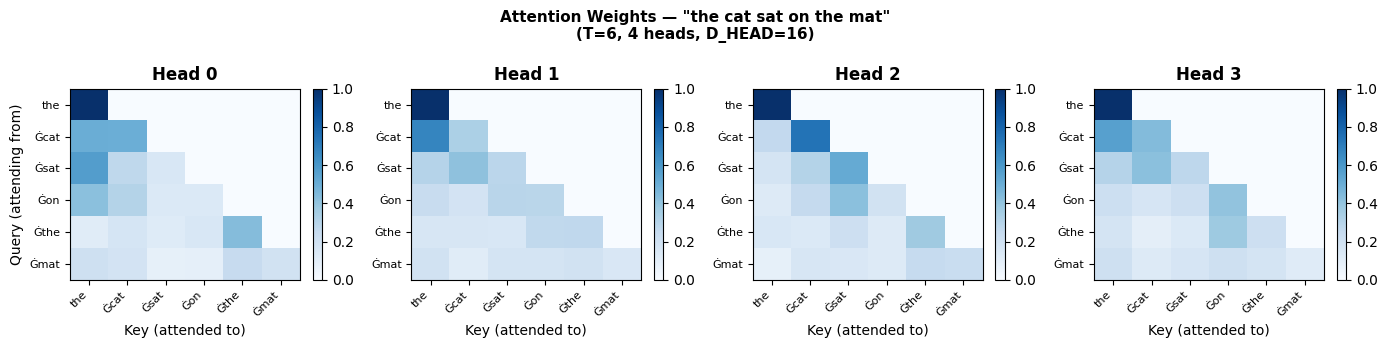


  Figure saved → '02_attention.png'


In [20]:
# ── 12. Figures ───────────────────────────────────────────────────────────────

# ── Figure A: Attention weights per head ─────────────────────────────────────

fig_a, axes_a = plt.subplots(1, N_HEADS, figsize=(3.5 * N_HEADS, 3.5))
fig_a.suptitle(
    f'Attention Weights — "{SENTENCE}"\n'
    f'(T={T}, {N_HEADS} heads, D_HEAD={D_HEAD})',
    fontsize=11, fontweight="bold"
)

for h in range(N_HEADS):
    ax = axes_a[h]
    w  = attn_w[h].detach().numpy()   # (T, T)
    im = ax.imshow(w, vmin=0, vmax=1, cmap="Blues", aspect="auto")
    ax.set_title(f"Head {h}", fontweight="bold")
    ax.set_xticks(range(T)); ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(T)); ax.set_yticklabels(tokens, fontsize=8)
    ax.set_xlabel("Key (attended to)")
    if h == 0:
        ax.set_ylabel("Query (attending from)")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig("02_attention.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Figure saved → '02_attention.png'")

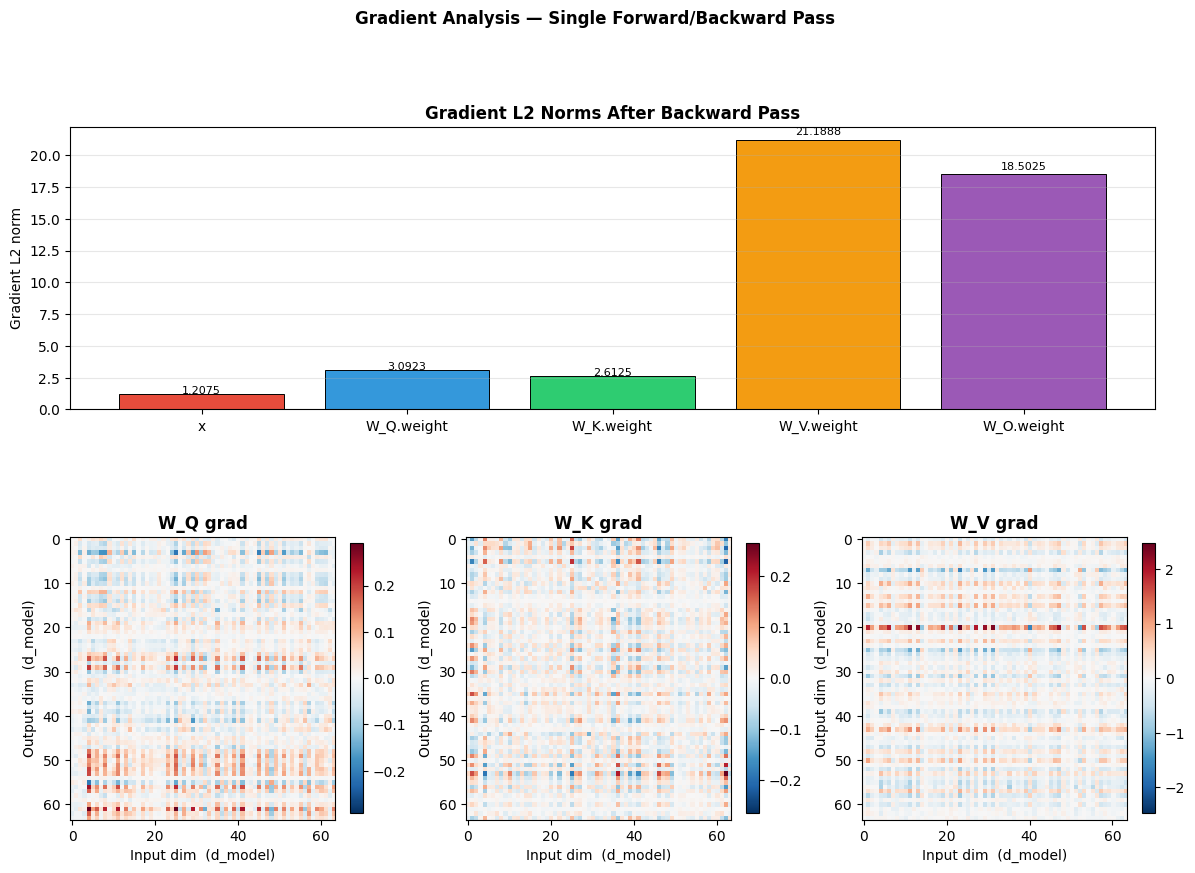

  Figure saved → '02_grads.png'


In [21]:
# ── Figure B: Gradient summary ────────────────────────────────────────────────

fig_b = plt.figure(figsize=(14, 9))
gs    = gridspec.GridSpec(2, 3, figure=fig_b, hspace=0.45, wspace=0.35)

# (a) Grad L2 norm bar chart
ax_bar = fig_b.add_subplot(gs[0, :])
names  = list(params.keys())
norms  = [params[n].grad.norm().item() for n in names]
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]
bars   = ax_bar.bar(names, norms, color=colors, edgecolor="black", linewidth=0.7)
ax_bar.set_ylabel("Gradient L2 norm")
ax_bar.set_title("Gradient L2 Norms After Backward Pass", fontweight="bold")
ax_bar.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, norms):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, val * 1.02,
                f"{val:.4f}", ha="center", fontsize=8)

# (b-d) W_Q, W_K, W_V gradient heatmaps
projection_grads = [
    ("W_Q grad", W_Q.weight.grad),
    ("W_K grad", W_K.weight.grad),
    ("W_V grad", W_V.weight.grad),
]

for col, (title, g) in enumerate(projection_grads):
    ax = fig_b.add_subplot(gs[1, col])
    g_np  = g.detach().numpy()
    vmax  = np.abs(g_np).max()
    im    = ax.imshow(g_np, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Input dim  (d_model)")
    ax.set_ylabel("Output dim  (d_model)")
    plt.colorbar(im, ax=ax, fraction=0.046)

fig_b.suptitle(
    "Gradient Analysis — Single Forward/Backward Pass",
    fontsize=12, fontweight="bold", y=1.01
)
plt.savefig("02_grads.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Figure saved → '02_grads.png'")

In [22]:
# ── 13. Gradient interpretation ───────────────────────────────────────────────

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)
print("""
  W_Q grad[i, j]  tells us: how much does the loss change if we
  increase W_Q[i,j] by ε?  A large value means this weight strongly
  influenced which positions attended to which.

  W_K grad[i, j]  — same idea for the key projection.
  W_V grad[i, j]  — same for the value projection (what information
                    gets aggregated once attention weights are set).

  Notice that x.grad has shape (T, d_model): one gradient vector per
  token position.  The gradient at position i depends on ALL positions
  j ≥ i (because they could attend back to i) — this is the global
  receptive field of attention, vs. the local field of convolutions.

  Run this script again with a different sentence to see how the
  gradient structure changes with different token patterns.
""")


INTERPRETATION

  W_Q grad[i, j]  tells us: how much does the loss change if we
  increase W_Q[i,j] by ε?  A large value means this weight strongly
  influenced which positions attended to which.
 
  W_K grad[i, j]  — same idea for the key projection.
  W_V grad[i, j]  — same for the value projection (what information
                    gets aggregated once attention weights are set).
 
  Notice that x.grad has shape (T, d_model): one gradient vector per
  token position.  The gradient at position i depends on ALL positions
  j ≥ i (because they could attend back to i) — this is the global
  receptive field of attention, vs. the local field of convolutions.
 
  Run this script again with a different sentence to see how the
  gradient structure changes with different token patterns.

